# 02. Preprocessing

Continuing from `sold_df` in 01_exploration.ipynb (monthly-merged CRMLSSold*.csv data, Residential / SingleFamilyResidence), we run preprocessing here.

`fit` for preprocessing (missing-value imputation, scaling, encoding) must be done only on the train set, and only `transform` is applied to the test set and the final cleaned CSV.


In [29]:
import glob
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42


## 1. Load merged dataset

If `merged_sales_data.csv` (created in 01_exploration.ipynb) already exists, load it directly.

In [ ]:
df = pd.read_csv("merged_sales_data.csv", low_memory=False)
df["date"] = pd.to_datetime(df["date"])

df["year_month"] = df["date"].dt.to_period("M")
print(df.shape)
df.head()


(166725, 80)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,date,year_month
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN,2025-10-01,2025-10
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN,2025-10-01,2025-10
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN,2025-10-01,2025-10
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,False,2.0,NaN,91901,NaN,NaN,NaN,2025-10-01,2025-10
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,False,2.0,NaN,92115,NaN,NaN,NaN,2025-10-01,2025-10


## 2. Define target and remove unusable rows

Rows with a missing target (`ClosePrice`) can't be used for training/evaluation, so they're dropped.

In [16]:
target = "ClosePrice"

before = len(df)
df = df.dropna(subset=[target]).copy()
print(f"Dropped {before - len(df)} rows with missing target ({target})")


Dropped 0 rows with missing target (ClosePrice)


## 3. Missing value overview 

First check the missing-value ratio per column, then decide how to handle each one based on the following rule:

- Columns with a very high missing ratio (default: over 50%): treated as carrying little information, so the column itself is dropped
- Columns with some missing values: values are imputed (median for numeric, most_frequent for categorical), and `SimpleImputer(add_indicator=True)` automatically adds a flag (indicator) column marking which rows were originally missing

The threshold is controlled by a single `MISSING_DROP_THRESHOLD` variable.

In [17]:
MISSING_DROP_THRESHOLD = 0.5  # drop a column if more than 50% of it is missing

missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_report = missing_ratio[missing_ratio > 0].to_frame("missing_ratio")
print(f"Columns with missing values: {len(missing_report)} / {df.shape[1]}")
missing_report.head(20)


Columns with missing values: 61 / 80


,missing_ratio
MiddleOrJuniorSchoolDistrict,1.000000
AboveGradeFinishedArea,1.000000
BusinessType,1.000000
ElementarySchoolDistrict,1.000000
FireplacesTotal,1.000000
CoveredSpaces,1.000000
TaxYear,1.000000
TaxAnnualAmount,1.000000
WaterfrontYN,0.999437
BelowGradeFinishedArea,0.992778


In [ ]:
high_missing_cols = missing_ratio[missing_ratio > MISSING_DROP_THRESHOLD].index.tolist()

# Exclude target/date-related columns in case they accidentally end up in the drop list
high_missing_cols = [c for c in high_missing_cols if c not in [target, "date", "year_month"]]

print(f"Columns dropped for exceeding {MISSING_DROP_THRESHOLD:.0%} missing ({len(high_missing_cols)}):")
print(high_missing_cols)

df = df.drop(columns=high_missing_cols)


Columns dropped for exceeding 50% missing (23):
['MiddleOrJuniorSchoolDistrict', 'AboveGradeFinishedArea', 'BusinessType', 'ElementarySchoolDistrict', 'FireplacesTotal', 'CoveredSpaces', 'TaxYear', 'TaxAnnualAmount', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName', 'LotSizeDimensions', 'BuildingAreaTotal', 'CoBuyerAgentFirstName', 'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool', 'CoListAgentFirstName', 'CoListAgentLastName', 'AssociationFeeFrequency', 'CoListOfficeName', 'SubdivisionName']


## 4. Feature selection (removing leakage / ID columns)

Besides the target and date-related columns, the following types are also excluded since they're unsuitable for model training:

- ID / key / URL / photo / free-text (remarks) columns: identified by keywords in the column name (see `LEAKAGE_KEYWORDS` below)
- High-cardinality object columns where nearly every value is unique (e.g. address strings, MLS numbers): these don't generalize well and would blow up the column count under One-Hot encoding

In [30]:
LEAKAGE_KEYWORDS = [
    "id", "key", "url", "photo", "remark", "address", "street",
    "agent", "office", "mlsnumber", "mlsstatus", "listingcontract",
]

def looks_like_id_or_leakage(col_name: str) -> bool:
    name = col_name.lower()
    return any(kw in name for kw in LEAKAGE_KEYWORDS)

keyword_flagged = [c for c in df.columns if looks_like_id_or_leakage(c) and c not in [target]]

# Object columns that are nearly all-unique (>90% of row count) are also treated as ID-like
object_cols = df.select_dtypes(include=["object"]).columns
high_cardinality_flagged = [
    c for c in object_cols
    if c not in keyword_flagged
    and df[c].nunique(dropna=True) / len(df) > 0.9
]

manual_drop_cols = [target, "date", "year_month"]

drop_cols = sorted(set(manual_drop_cols + keyword_flagged + high_cardinality_flagged))
# Keep only columns that actually exist (some may already be gone via high_missing_cols)
drop_cols = [c for c in drop_cols if c in df.columns]

print(f"Final drop_cols ({len(drop_cols)}):")
print(drop_cols)


Final drop_cols (22):
['BuyerAgentAOR', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerOfficeName', 'ClosePrice', 'ListAgentAOR', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentFullName', 'ListAgentLastName', 'ListOfficeName', 'ListingContractDate', 'ListingId', 'ListingKey', 'ListingKeyNumeric', 'MlsStatus', 'StreetNumberNumeric', 'UnparsedAddress', 'date', 'year_month']


In [20]:
X = df.drop(columns=drop_cols)
y = df[target]

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print(f"numeric_cols ({len(numeric_cols)}): {numeric_cols}")
print(f"categorical_cols ({len(categorical_cols)}): {categorical_cols}")


numeric_cols (17): ['OriginalListPrice', 'Latitude', 'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet']
categorical_cols (18): ['Flooring', 'ViewYN', 'PoolPrivateYN', 'CloseDate', 'PropertyType', 'MLSAreaMajor', 'CountyOrParish', 'AttachedGarageYN', 'PropertySubType', 'City', 'ContractStatusChangeDate', 'PurchaseContractDate', 'StateOrProvince', 'FireplaceYN', 'Levels', 'NewConstructionYN', 'HighSchoolDistrict', 'PostalCode']


## 5. Preprocessing pipeline

- Numeric: median imputation + flag (`add_indicator=True`) + StandardScaler
- Categorical: most_frequent imputation + flag + OneHotEncoder(`handle_unknown="ignore"`)

In [21]:
def build_pipeline():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent", add_indicator=True)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        # On older scikit-learn (<1.2), use sparse=False instead of sparse_output
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ])


## 6. Time-based train/test split

- Test set: data from the most recent month (`test_month`)
- Train set: the X months immediately preceding test_month (test_month itself is never included)
- X is not fixed but tuned; candidates [3, 6, 9, 12] are tried only within the range actually available in the data.

In [22]:
all_months = sorted(df["year_month"].unique())
test_month = all_months[-1]

months_available_for_train = len(all_months) - 1  # everything except test_month
candidate_windows = [w for w in [3, 6, 9, 12] if w <= months_available_for_train]

if not candidate_windows:
    # If very little data is available, fall back to a single maximal window
    candidate_windows = [months_available_for_train] if months_available_for_train >= 1 else []

if not candidate_windows:
    raise ValueError("No months are available to use as a training set. Check the date range of the data.")

print(f"All available months: {all_months}")
print(f"Test month: {test_month}")
print(f"Candidate training windows (months): {candidate_windows}")


All available months: [Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M')]
Test month: 2026-05
Candidate training windows (months): [3, 6]


In [ ]:
results = []

for X_months in candidate_windows:
    train_months = all_months[-(X_months + 1):-1]

    train_df = df[df["year_month"].isin(train_months)].copy()
    test_df = df[df["year_month"] == test_month].copy()

    X_train = train_df.drop(columns=drop_cols)
    y_train = train_df[target]

    X_test = test_df.drop(columns=drop_cols)
    y_test = test_df[target]

    model = build_pipeline()
    model.fit(X_train, y_train)  # preprocessing is fit here, on train only

    pred = model.predict(X_test)  # only transform is applied to test (no leakage)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))  # squared=False was removed in newer sklearn, so use sqrt instead

    results.append({
        "training_window_months": X_months,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "train_months": [str(m) for m in train_months],
        "test_month": str(test_month),
        "MAE": mae,
        "RMSE": rmse,
    })

    print(f"[window={X_months:>2}] train_rows={len(train_df):>6} | MAE={mae:,.0f} | RMSE={rmse:,.0f}")


[window= 3] train_rows= 31758 | MAE=116,699 | RMSE=2,471,414
[window= 6] train_rows= 59442 | MAE=102,227 | RMSE=2,053,572


## 7. Compare X-month window performance

In [24]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values("RMSE").reset_index(drop=True)
results_df_sorted


,training_window_months,n_train_rows,n_test_rows,train_months,test_month,MAE,RMSE
0,6,59442,12024,"[2025-11, 2025-12, 2026-01, 2026-02, 2026-03, ...",2026-05,102226.771243,2.053572e+06
1,3,31758,12024,"[2026-02, 2026-03, 2026-04]",2026-05,116698.687019,2.471414e+06


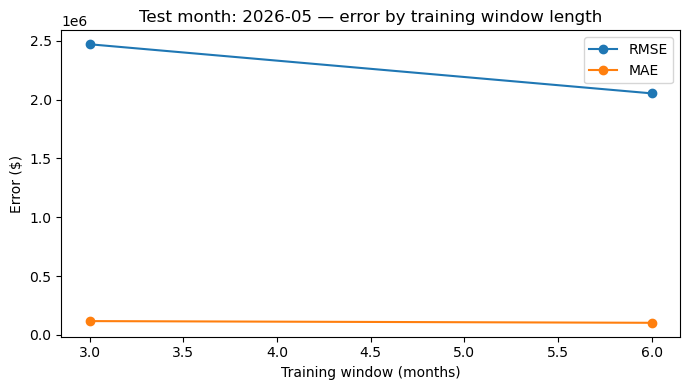

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(results_df["training_window_months"], results_df["RMSE"], marker="o", label="RMSE")
plt.plot(results_df["training_window_months"], results_df["MAE"], marker="o", label="MAE")
plt.xlabel("Training window (months)")
plt.ylabel("Error ($)")
plt.title(f"Test month: {test_month} — error by training window length")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Choose best X and rebuild final train/test split

In [26]:
best_X = int(results_df_sorted.iloc[0]["training_window_months"])
print(f"Best training window: {best_X} months (lowest RMSE)")

best_train_months = all_months[-(best_X + 1):-1]

train_df = df[df["year_month"].isin(best_train_months)].copy()
test_df = df[df["year_month"] == test_month].copy()

print(f"Final train months: {[str(m) for m in best_train_months]}")
print(f"Final test month: {test_month}")
print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")


Best training window: 6 months (lowest RMSE)
Final train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Final test month: 2026-05
Train rows: 59442 | Test rows: 12024


## 9. Fit final preprocessing pipeline (best X) and evaluate

In [27]:
X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

final_pipeline = build_pipeline()
final_pipeline.fit(X_train, y_train)  # fit only on the final train set

final_pred = final_pipeline.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print(f"Final model (window={best_X}) — MAE: {final_mae:,.0f}, RMSE: {final_rmse:,.0f}")


Final model (window=6) — MAE: 102,227, RMSE: 2,053,572


## 10. Create cleaned CSV

The preprocessor inside `final_pipeline` was already fit only on best_train_months. so, I apply that same fitted preprocessor with transform only to the full dataset (`df`) to build the cleaned CSV. In other words, the imputation values and scaling statistics for rows outside the training window (e.g. test_month) still come from the training data and are never recomputed

In [ ]:
X_cleaned = df.drop(columns=drop_cols)

cleaned_array = final_pipeline.named_steps["preprocessor"].transform(X_cleaned)

# Column names must be pulled explicitly since OneHotEncoder + add_indicator expand the column count
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()

cleaned_df = pd.DataFrame(
    cleaned_array.toarray() if hasattr(cleaned_array, "toarray") else cleaned_array,
    columns=feature_names,
    index=df.index,
)

cleaned_df[target] = df[target].values
cleaned_df["year_month"] = df["year_month"].astype(str).values
cleaned_df["date"] = df["date"].values
cleaned_df["split"] = np.where(
    df["year_month"].isin(best_train_months), "train",
    np.where(df["year_month"] == test_month, "test", "unused")
)

cleaned_df.to_csv("cleaned_preprocessed_data.csv", index=False)
print(f"Saved cleaned_preprocessed_data.csv - shape: {cleaned_df.shape}")

# Also save the window-comparison results for reproducibility/reporting
results_df.to_csv("window_selection_results.csv", index=False)
print("Saved window_selection_results.csv")


Saved cleaned_preprocessed_data.csv — shape: (83495, 4962)
Saved window_selection_results.csv


## Summary

- Missing values: columns over 50% missing are dropped; the rest are imputed, with `add_indicator` automatically generating a flag column for each
- Categorical encoding: `OneHotEncoder(handle_unknown="ignore")`
- Numeric normalization: `StandardScaler` (not required for tree models, but kept in case the model is swapped later)
- Train/test split: the most recent month is the test set, and the X months right before it are the train set — X is chosen as whichever of [3, 6, 9, 12] gave the lowest RMSE (`best_X`, see the cell 9 output above)
- All preprocessing `fit` happens only on the final train window; only `transform` is applied to the test set and the full cleaned CSV → prevents data leakage
- Deliverables: `cleaned_preprocessed_data.csv`, `window_selection_results.csv`
